In [1]:
# https://colab.research.google.com/github/lschmiddey/fastpages_/blob/master/_notebooks/2021-03-14-tabular-data-variational-autoencoder.ipynb#scrollTo=hvE-JP4uhWxE

In [2]:
import pandas as pd
from sklearn import preprocessing
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from tqdm import tqdm
from datetime import datetime
from path import Path
import json 
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Model Configuration 

In [3]:
dataset_name = 'Dataset_1_with_4_anomaly'
batch_size = 1024
seed = 42
np.random.seed(seed)
train_loss_delta = 0.001
ROOT = Path().parent
SAVED_MODELS = ROOT / 'saved_models' / dataset_name

## Loading the Dataset

In [4]:
df = pd.read_csv(f'{dataset_name}.csv',index_col='applicant_id')
df = pd.get_dummies(df, columns=['Occupation','cholesterol_level','smoking_status','Location','Alcohol','exercise','Gender','covered_by_any_other_company' ])
df = df[-np.isnan(df['bmi'])]
df = df.drop(columns=['Year_last_admitted'])
np_df = df.values.reshape(-1, df.shape[1]).astype('float32')

In [5]:
def load_and_standardize_data(df):
    '''
        Split the dataset into training and Testing chunks and Applying StandardScaler to scale the data.
    '''
    # randomly split
    X_train, X_test = train_test_split(df, test_size=0.3, random_state=seed)

    # standardize values
    scaler = preprocessing.StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)   
    return X_train, X_test, scaler

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Generic Dataset class for easy model training 

In [7]:
class DataBuilder(Dataset):
    def __init__(self,df, train=True,):
        self.X_train, self.X_test, self.standardizer = load_and_standardize_data(df)
        if train:
            self.x = torch.from_numpy(self.X_train)
            self.len=self.x.shape[0]
        else:
            self.x = torch.from_numpy(self.X_test)
            self.len=self.x.shape[0]
        del self.X_train
        del self.X_test 
    def __getitem__(self,index):      
        return self.x[index]
    def __len__(self):
        return self.len

### Creating training dataset object

In [8]:
traindata_set=DataBuilder(np_df, train=True)
testdata_set=DataBuilder(np_df, train=False)

trainloader=DataLoader(dataset=traindata_set,batch_size=batch_size)
testloader=DataLoader(dataset=testdata_set,batch_size=batch_size)

## Loss function class 

In [9]:
class customLoss(nn.Module):
    def __init__(self):
        super(customLoss, self).__init__()
        self.mse_loss = nn.MSELoss(reduction="sum")
    
    def forward(self, x_recon, x, mu, logvar):
        loss_MSE = self.mse_loss(x_recon, x)
        loss_KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return loss_MSE + loss_KLD

# VAE Autoencoder class 

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, D_in, H=50, H2=12, latent_dim=32,seed=42,lr=0.001):
        self.train_losses = []
        self.test_losses = []
        self.epoches = 100
        self.D_in = D_in
        self.H = H
        self.H2 = H2
        self.latent_dim = latent_dim
        self.lr = lr

        torch.manual_seed(seed)        
        #Encoder
        super(Autoencoder,self).__init__()
        self.linear1=nn.Linear(D_in,H)
        self.lin_bn1 = nn.BatchNorm1d(num_features=H)
        self.linear2=nn.Linear(H,H2)
        self.lin_bn2 = nn.BatchNorm1d(num_features=H2)
        self.linear3=nn.Linear(H2,H2)
        self.lin_bn3 = nn.BatchNorm1d(num_features=H2)
        
        # Latent vectors mu and sigma
        self.fc1 = nn.Linear(H2, latent_dim)
        self.bn1 = nn.BatchNorm1d(num_features=latent_dim)
        self.fc21 = nn.Linear(latent_dim, latent_dim)
        self.fc22 = nn.Linear(latent_dim, latent_dim)

        # Sampling vector
        self.fc3 = nn.Linear(latent_dim, latent_dim)
        self.fc_bn3 = nn.BatchNorm1d(latent_dim)
        self.fc4 = nn.Linear(latent_dim, H2)
        self.fc_bn4 = nn.BatchNorm1d(H2)
        
        # Decoder
        self.linear4=nn.Linear(H2,H2)
        self.lin_bn4 = nn.BatchNorm1d(num_features=H2)
        self.linear5=nn.Linear(H2,H)
        self.lin_bn5 = nn.BatchNorm1d(num_features=H)
        self.linear6=nn.Linear(H,D_in)
        self.lin_bn6 = nn.BatchNorm1d(num_features=D_in)
        
        self.relu = nn.ReLU()

    def getModelConfig(self):
        return self.D_in,self.H, self.H2, self.latent_dim, self.epoches, self.lr
        
    def setOptimizer(self,optim):
        self.optimizer = optim
    
    def setLossfn(self,customLoss):
        self.loss = customLoss  


    def encode(self, x):
        lin1 = self.relu(self.lin_bn1(self.linear1(x)))
        lin2 = self.relu(self.lin_bn2(self.linear2(lin1)))
        lin3 = self.relu(self.lin_bn3(self.linear3(lin2)))

        fc1 = F.relu(self.bn1(self.fc1(lin3)))

        r1 = self.fc21(fc1)
        r2 = self.fc22(fc1)
        
        return r1, r2
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = Variable(std.data.new(std.size()).normal_())
            return eps.mul(std).add_(mu)
        else:
            return mu
        
    def decode(self, z):
        fc3 = self.relu(self.fc_bn3(self.fc3(z)))
        fc4 = self.relu(self.fc_bn4(self.fc4(fc3)))

        lin4 = self.relu(self.lin_bn4(self.linear4(fc4)))
        lin5 = self.relu(self.lin_bn5(self.linear5(lin4)))
        return self.lin_bn6(self.linear6(lin5))
        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
    
    def trainModel(self,trainloader):
        self.train()
        train_loss = 0
        for batch_idx, data in enumerate(trainloader):
            data = data.to(device)
            self.optimizer.zero_grad()
            recon_batch, mu, logvar = self(data)
            loss = self.loss(recon_batch, data, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            self.optimizer.step()
            self.train_losses.append(train_loss / len(trainloader.dataset))
        return np.mean(self.train_losses) 
    
    def testModel(self,testloader):
        with torch.no_grad():
            test_loss = 0
            for batch_idx, data in enumerate(testloader):
                data = data.to(device)
                self.optimizer.zero_grad()
                recon_batch, mu, logvar = self(data)
                loss = self.loss(recon_batch, data, mu, logvar)
                test_loss += loss.item()
                self.test_losses.append(test_loss / len(testloader.dataset))
        return np.mean(self.test_losses)

# Creating list of models with different architecture

In [11]:
# List of models
models = []

# =========== Model 1 ===========
D_in = 51
H = D_in // 2  
H2 = H // 2 
latent_dim = H2 // 2 
lr=1e-2

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 850

models.append(model)

# =========== Model 2 ===========
D_in = 51
H =  128
H2 =  64 
latent_dim =  32
lr=1e-2

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 1400

models.append(model)

# =========== Model 3 ===========
D_in = 51
H =  64
H2 =  32  
latent_dim =  10
lr=1e-2

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 4 ===========
D_in = 51
H =  64
H2 =  32  
latent_dim =  5
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 5 ===========
D_in = 51
H =  64
H2 =  32  
latent_dim =  30
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 6 ===========
D_in = 51
H =  64
H2 =  32  
latent_dim =  20
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 7 ===========
D_in = 51
H =  40
H2 =  30  
latent_dim =  20
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 8 ===========
D_in = 51
H =  40
H2 =  30  
latent_dim =  10
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 9 ===========
D_in = 51
H =  30
H2 =  20
latent_dim =  10
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)


# =========== Model 10 ===========
D_in = 51
H =  30
H2 =  20  
latent_dim =  5
lr=1e-3

model = Autoencoder(D_in, H, H2,latent_dim,seed,lr).to(device)
model.setLossfn(customLoss())
model.setOptimizer(optim.Adam(model.parameters(), lr=lr))

model.epoches = 950

models.append(model)





In [12]:
def createExperimentFolder(SAVED_MODELS):
    """
    Get the folder where to store the experiment. 
    The folder is named with the current date and time.
    
    Returns:
        Path: the path to the folder where to store the experiment
    """

    checkpoint_folder = SAVED_MODELS / datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    checkpoint_folder.makedirs_p()
    return checkpoint_folder

In [13]:
def saveModelConfig(experiment_folder,model,count):   
   """
   Saving the model config JSON file to config.json
   """ 
   with open(experiment_folder / f'model-{count}_config.json', 'w') as f:
      D_in,H, H2, latent_dim, epoches,lr = model.getModelConfig()
      dict1 ={ 
         "Model": { 
            "Dataset_name" : dataset_name,
            "input_dim" : D_in,
            "H" :H,
            "H2" : H2,
            "latent_dim" : latent_dim,
            "Epochs" : epoches,
            "lr" : lr,
         }
      } 
      json.dump(dict1, f, indent = 6)

# Model Training Loop

* Training model-1.


  0%|          | 0/850 [00:00<?, ?it/s]

 52%|█████▏    | 438/850 [02:43<02:33,  2.69it/s]


     Early Stopping..
     Final Epoch 439
* Training model-2.


 67%|██████▋   | 936/1400 [07:25<03:40,  2.10it/s]


...

     Final Epoch 950
* Training model-9.


100%|██████████| 950/950 [05:26<00:00,  2.91it/s]


     Final Epoch 950
* Training model-10.


100%|██████████| 950/950 [05:20<00:00,  2.97it/s]

     Final Epoch 950


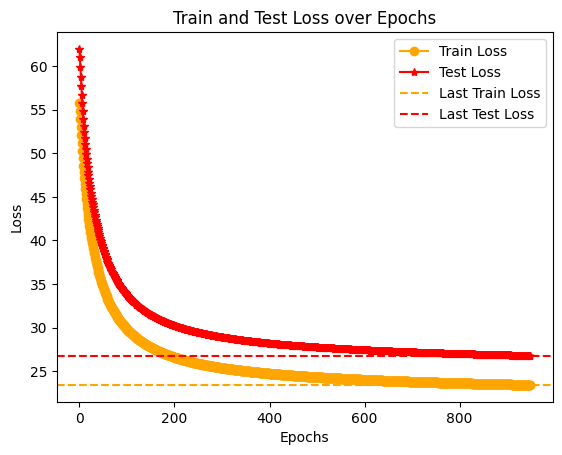

In [14]:
# Creating an experimenet folder
experiment_folder = createExperimentFolder(SAVED_MODELS)
count=0
early_stop = False
for model in models:
    count += 1
    train_loss = []
    test_loss = []
    # Saving the model config to config.json in the experiment folder
    saveModelConfig(experiment_folder,model,count)
    print(f'* Training model-{count}.')
    for epoch in tqdm(range(1, model.epoches + 1)):
        train_loss.append(model.trainModel(trainloader))
        test_loss.append(model.testModel(testloader))

        plt.clf()
        plt.plot(train_loss, label='Train Loss', marker='o',color='orange')

        # Plotting test_loss
        plt.plot(test_loss, label='Test Loss', marker='*',color='red')

        # Adding horizontal lines at the last values of train_loss and test_loss
        plt.axhline(y=train_loss[-1], color='orange', linestyle='--', label='Last Train Loss')
        plt.axhline(y=test_loss[-1], color='red', linestyle='--', label='Last Test Loss')


        # # Adding labels and title
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train and Test Loss over Epochs')

        # # Adding legend
        plt.legend()
        plt.savefig(experiment_folder / f'model-{count}_autoencoder_training')
        
        # Early Stopping
        if epoch > 2:
            if (np.abs(train_loss[-1] - train_loss[-2])) < train_loss_delta:
                print('     Early Stopping..')
                break

    torch.save(model.state_dict(), experiment_folder / f'model-{count}_autoencoder.pth')
    print(f'     Final Epoch {epoch}')
    # Saving the training results in results.json
    with open(experiment_folder / f'model-{count}_results.json', 'w') as f:
        dict1 ={ 
            "Model": { 
            "train_loss" : train_loss[-1],
            "test_loss" : test_loss[-1],
            "Early_stop" : early_stop,
            "Train_epoch" : epoch
            }
        } 
        json.dump(dict1, f, indent = 6)

# Model Inference

In [15]:
# standardize values of the the original dataset
scaler = traindata_set.standardizer
df_scaled = scaler.fit_transform(np_df)
df_scaled.shape

(24014, 51)

### Calculating Reconstruction Error from all the models trained and append in the dataframe

In [16]:
# Convert the NumPy array to a PyTorch tensor
input_data = torch.tensor(df_scaled).to(device)  # 'device' should be the same as the device where your model is located
count = 0
for model in models:
    count += 1
    # Pass the data through the model to get the reconstructed output
    with torch.no_grad():
        decoded_output = model(input_data) 

    # Calculate Mean Squared Error (MSE) for each row
    mse_errors = F.mse_loss(decoded_output[0], input_data, reduction='none')
    mse_errors = mse_errors.mean(dim=1).cpu().numpy()  # Calculate mean along columns and convert to NumPy

    # Create a DataFrame with the reconstruction error for each row
    reconstruction_error_df = pd.DataFrame({f'model-{count}_ReconstructionError': mse_errors})
    reconstruction_error_df.index = df.index
    df = pd.concat([df, reconstruction_error_df], axis=1)
    # Display the DataFrame

df['AvgReconstructionError'] = df.iloc[:, -len(models):].mean(axis=1)

In [17]:
df.loc[df['AvgReconstructionError'] > 0.7].sort_values(by='applicant_id',ascending=True)

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,daily_avg_steps,age,heart_decs_history,other_major_decs_history,avg_glucose_level,bmi,...,model-2_ReconstructionError,model-3_ReconstructionError,model-4_ReconstructionError,model-5_ReconstructionError,model-6_ReconstructionError,model-7_ReconstructionError,model-8_ReconstructionError,model-9_ReconstructionError,model-10_ReconstructionError,AvgReconstructionError
applicant_id,,,,,,,,,,,,,,,,,,,,,
1001,50,1,1,2,10000,28,1,0,97,31.2,...,1.604524,6.755629,7.199419,6.886446,6.803629,7.281267,7.011806,7.375566,7.607117,6.595628
1002,1,2,1,2,2048,20,1,0,97,20.5,...,0.622251,1.214032,1.612412,1.186721,1.257524,1.602055,1.306488,1.322765,1.508513,1.308079
1003,3,3,1,2,3307,38,1,0,97,29.0,...,0.697050,1.420971,1.270898,0.951516,1.069373,1.182884,1.298898,1.376232,1.627332,1.208724
1004,8,4,1,2,6000,51,0,0,97,24.0,...,1.455539,1.993284,1.696571,1.175889,1.342589,1.335145,1.434192,1.481207,1.960212,1.560946
5028,3,1,0,1,7887,65,0,1,157,23.2,...,0.559900,0.823005,0.941064,0.547666,0.536417,0.547583,0.670988,0.878384,1.070306,0.775458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29916,0,1,1,4,5083,64,0,1,215,27.2,...,0.380149,0.779136,0.905611,0.465127,0.560891,0.752200,0.837201,0.882393,1.052642,0.759191
29944,8,0,0,2,5799,54,1,1,83,28.6,...,0.366145,0.777376,0.914705,0.573050,0.630296,0.851096,1.011549,1.124352,1.318235,0.867336
29982,7,1,0,6,4564,28,1,1,83,33.5,...,0.274465,0.564589,1.053374,0.851108,0.507781,0.870756,0.809996,0.974711,1.318544,0.825984


{'whiskers': [<matplotlib.lines.Line2D at 0x2a79c683d50>,
 'caps': [<matplotlib.lines.Line2D at 0x2a7a2652f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x2a79c683610>],
 'medians': [<matplotlib.lines.Line2D at 0x2a7a23fe310>],
 'fliers': [],
 'means': []}

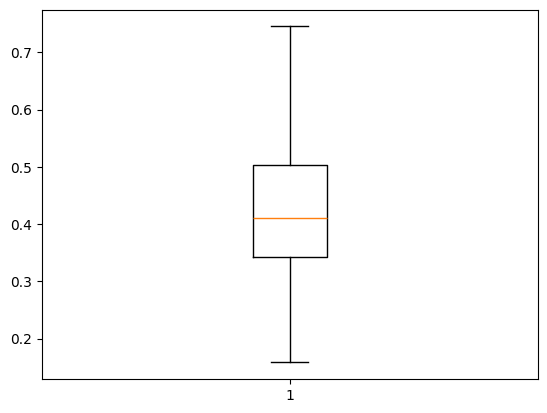

In [18]:
plt.boxplot(df['AvgReconstructionError'],showfliers=False)

{'whiskers': [<matplotlib.lines.Line2D at 0x2a7a4b49f10>,
 'caps': [<matplotlib.lines.Line2D at 0x2a7a4b52190>,
 'boxes': [<matplotlib.lines.Line2D at 0x2a7a4caca50>],
 'medians': [<matplotlib.lines.Line2D at 0x2a7a4b52ed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2a7a4b53350>],
 'means': []}

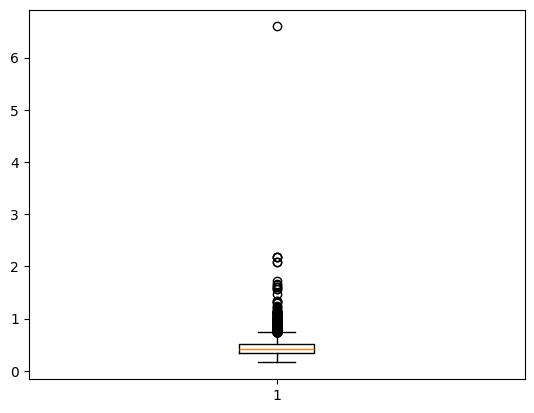

In [19]:
plt.boxplot(df['AvgReconstructionError'],showfliers=True)

In [83]:
df.to_csv(f'VAE_{dataset_name}_10_models.csv')

In [84]:
temp = df.iloc[:,:-8]
temp['AvgReconstructionError'] = df.iloc[:,-11:-8].mean(axis=1)
temp.to_csv(f'VAE_{dataset_name}_3_models.csv')

In [95]:
temp = None
temp = df.iloc[:,:-6]
temp['AvgReconstructionError'] = df.iloc[:,-11:-6].mean(axis=1)
temp.to_csv(f'VAE_{dataset_name}_5_models.csv')